<a href="https://colab.research.google.com/github/juvowen/AlgoTrading/blob/main/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HYPOTHESIS:
Does weekday prices prodvide any prodictability

do we have a positive E[r | weekday(t)]

In [1]:
%pip install xgboost

In [15]:
import pandas
import numpy as np
import yfinance as yf

df = yf.download("BTC-USD",period = "6mo",interval = '1d')
df

/tmp/ipykernel_6237/686688956.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD",period = "6mo",interval = '1d')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-03-28,66319.695312,67232.859375,65906.742188,66338.500000,20924883455
2026-03-29,65954.921875,67052.953125,64971.707031,66319.695312,21645889785
2026-03-30,66691.445312,68087.289062,65759.804688,65958.351562,37694994180
2026-03-31,68233.312500,68495.273438,65950.437500,66694.585938,42997691338
2026-04-01,68078.554688,69230.359375,67555.359375,68232.890625,36465393617
...,...,...,...,...,...
2026-09-24,84379.062500,84876.226562,82906.617188,84381.593750,37106744985
2026-09-25,84034.921875,85230.054688,83165.531250,84379.515625,34118533914


In [16]:
df['returns'] = df['Close'].pct_change()
df['weekday'] = df.index.day_of_week
df.dropna(inplace=True)

In [17]:
df

Price,Close,High,Low,Open,Volume,returns,weekday
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,
Date,,,,,,,
2026-03-29,65954.921875,67052.953125,64971.707031,66319.695312,21645889785,-0.005500,6
2026-03-30,66691.445312,68087.289062,65759.804688,65958.351562,37694994180,0.011167,0
2026-03-31,68233.312500,68495.273438,65950.437500,66694.585938,42997691338,0.023119,1
2026-04-01,68078.554688,69230.359375,67555.359375,68232.890625,36465393617,-0.002268,2
2026-04-02,66888.570312,68633.148438,65725.257812,68077.898438,39323384518,-0.017480,3
...,...,...,...,...,...,...,...
2026-09-24,84379.062500,84876.226562,82906.617188,84381.593750,37106744985,-0.000047,3
2026-09-25,84034.921875,85230.054688,83165.531250,84379.515625,34118533914,-0.004079,4


In [20]:
i = int(len(df) * .75)
df_train,df_test = df.iloc[:i].copy(),df.iloc[i:].copy()

#75 percent is for training, while 25 percent is for testing
df_train

Price,Close,High,Low,Open,Volume,returns,weekday
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,
Date,,,,,,,
2026-03-29,65954.921875,67052.953125,64971.707031,66319.695312,21645889785,-0.005500,6
2026-03-30,66691.445312,68087.289062,65759.804688,65958.351562,37694994180,0.011167,0
2026-03-31,68233.312500,68495.273438,65950.437500,66694.585938,42997691338,0.023119,1
2026-04-01,68078.554688,69230.359375,67555.359375,68232.890625,36465393617,-0.002268,2
2026-04-02,66888.570312,68633.148438,65725.257812,68077.898438,39323384518,-0.017480,3
...,...,...,...,...,...,...,...
2026-08-09,64844.886719,65401.691406,64677.601562,64906.550781,13234538380,-0.000921,6
2026-08-10,63910.585938,65321.839844,63752.566406,64845.382812,22384770392,-0.014408,0


In [22]:
#train xgboost model

import xgboost as xgb

model = xgb.XGBRegressor(max_depth=3,learning_rate=0.3)
model.fit(df_train[['weekday']] , df_train['returns'])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.3, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [23]:
tree_idx = 0

print(model.get_booster().get_dump(with_stats=True)[tree_idx])


0:[weekday <5] yes=1,no=2,missing=2,gain=0.0004680446,cover=138
	1:[weekday <1] yes=3,no=4,missing=4,gain=0.000207366567,cover=99
		3:leaf=0.000498194364,cover=20
		4:[weekday <3] yes=5,no=6,missing=6,gain=0.000172811677,cover=79
			5:leaf=-0.000994631439,cover=40
			6:leaf=-0.000109357832,cover=39
	2:leaf=0.000867303053,cover=39



In [29]:
#test

y_hat = model.predict(df_test[["weekday"]])
df_test['y_hat'] = y_hat
df_test[['weekday','returns','y_hat']]



Price,weekday,returns,y_hat
Ticker,,,
Date,,,
2026-08-14,4,-0.006728,-0.000907
2026-08-15,5,0.000774,0.002694
2026-08-16,6,-0.003263,0.002694
2026-08-17,0,0.026865,0.001397
2026-08-18,1,0.002704,-0.002606
2026-08-19,2,0.070894,-0.004235
2026-08-20,3,0.054378,-0.000116
2026-08-21,4,0.072603,-0.000907


In [31]:
#encode signal

df_test['signal'] = np.sign(df_test['y_hat'])
df_test['trade_return'] = df_test['signal']*df_test['returns']
df_test[['weekday','returns','y_hat','signal','trade_return']]

Price,weekday,returns,y_hat,signal,trade_return
Ticker,,,,,
Date,,,,,
2026-08-14,4,-0.006728,-0.000907,-1.0,0.006728
2026-08-15,5,0.000774,0.002694,1.0,0.000774
2026-08-16,6,-0.003263,0.002694,1.0,-0.003263
2026-08-17,0,0.026865,0.001397,1.0,0.026865
2026-08-18,1,0.002704,-0.002606,-1.0,-0.002704
2026-08-19,2,0.070894,-0.004235,-1.0,-0.070894
2026-08-20,3,0.054378,-0.000116,-1.0,-0.054378
2026-08-21,4,0.072603,-0.000907,-1.0,-0.072603


In [32]:
df_test['trade_return'].mean()

#negative mean

np.float64(-0.0015539829844676593)

In [34]:
(df_test['trade_return']>0).mean()
# we are winngin 60 percent of the time

np.float64(0.6086956521739131)

<Axes: title={'center': 'Gross Pnl'}, xlabel='Date'>

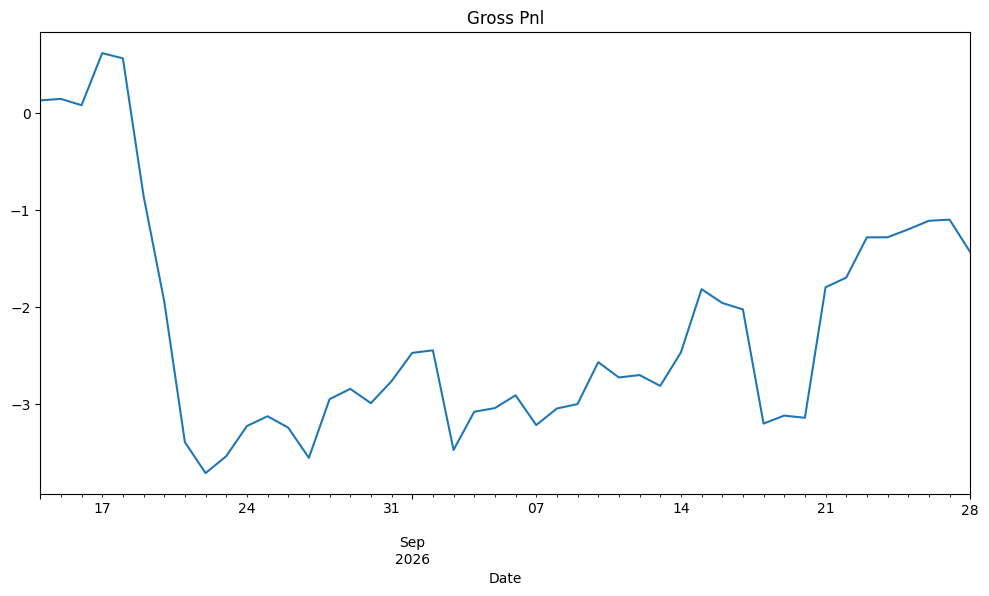

In [35]:
trade_size = 20
# the money we are risking

df_test['trade_gross_pnl'] = df_test['trade_return'] * trade_size
df_test['trade_gross_pnl'].cumsum().plot(title = 'Gross Pnl',figsize=(12,6))

<Axes: title={'center': 'Net PnL'}, xlabel='Date'>

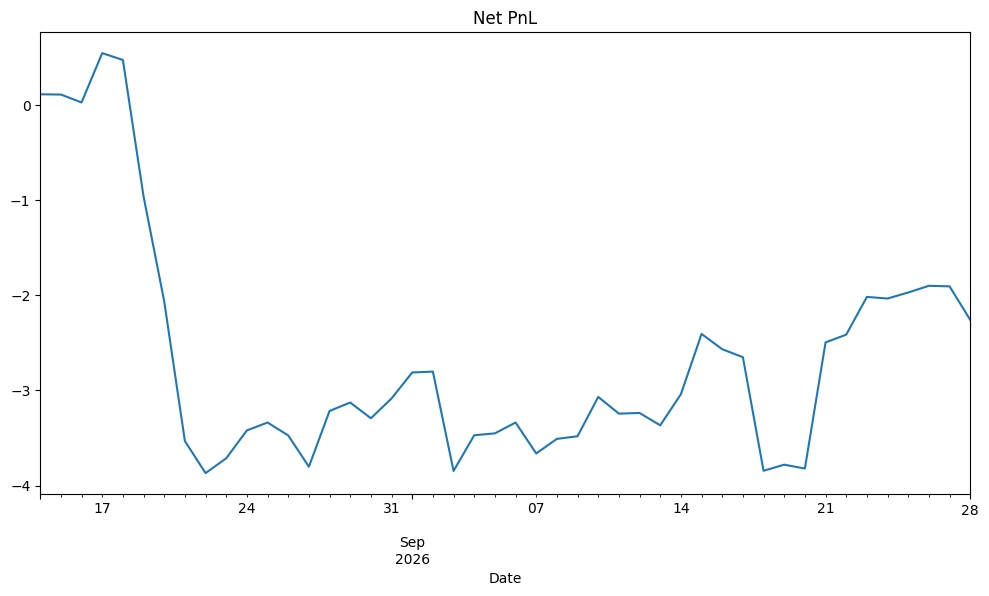

In [37]:
taker_fee = 0.00045

df_test['entry_value'] = trade_size
df_test['exit_value'] = trade_size + df_test['trade_gross_pnl']
df_test['taker_fee'] =(df_test['entry_value']+df_test['exit_value']) * taker_fee
df_test['trade_net_pnl'] = df_test['trade_gross_pnl'] - df_test['taker_fee']
df_test['trade_net_pnl'].cumsum().plot(title="Net PnL",figsize=(12,6))